# EDA PROJECT ASSIGNMENT: HR ANALYTICS-EMPLOYEE ATTRITION

# Project Title-HR Data Analysis & Understanding Attrition
## Submitted By: Sanjana Manthena

## Introdution
### This project is about every organization faces the problem of employee turnover. When people leave, the company loses good workers. They have to spend time and money hiring and training new people. This affects productivity and company growth
### The goal is to find the real reasons why people leave and give actionable recommendations to HR

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

## LOAD DATASET

In [2]:
# Load dataset
df = pd.read_csv('hr.csv')

# View first rows
display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## DATA UNDERSTANDING

In [3]:
# Shape of dataset
print("Shape:", df.shape)

# Columns
print("Columns:", df.columns)

# Info
df.info()

# Summary statistics
df.describe()

Shape: (1470, 35)
Columns: Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## DATA CLEANING

In [4]:
# 4.1 Missing values
print("Missing values:\n", df.isnull().sum())

# 4.2 Remove duplicates
df.drop_duplicates(inplace=True)

# 4.3 Drop irrelevant columns
# Reason: No analytical importance
df.drop(['EmployeeNumber','Over18','StandardHours','EmployeeCount'],
        axis=1, inplace=True, errors='ignore')

# 4.4 Clean categorical data
cat_cols = df.select_dtypes(include='object').columns

# Convert to lowercase & remove spaces
df[cat_cols] = df[cat_cols].apply(lambda x: x.str.lower().str.strip())

Missing values:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole     

### No missing values found, so no imputation was necessary.
- Over18 was dropped because all values are 'Y', providing no analytical value.




## FEATURE ENGINEERING

In [5]:
# Salary category
df['SalaryCategory'] = pd.cut(df['MonthlyIncome'],
                             bins=[0,3000,8000,20000],
                             labels=['low','medium','high'])

# Experience Level
df['ExperienceLevel'] = pd.cut(df['TotalWorkingYears'],
                              bins=[0,5,10,40],
                              labels=['fresher','mid','senior'])

## NUMPY OPERATIONS

In [6]:
# Convert to numpy array
income = df['MonthlyIncome'].values

print("Mean:", np.mean(income))
print("Median:", np.median(income))
print("Std Dev:", np.std(income))

Mean: 6502.931292517007
Median: 4919.0
Std Dev: 4706.355164823003


## BASIC ANALYSIS

In [7]:
# Attrition count
print(df['Attrition'].value_counts())

# Attrition percentage
attrition_rate = df['Attrition'].value_counts(normalize=True)['yes'] * 100
print("Attrition Rate:", attrition_rate)

Attrition
no     1233
yes     237
Name: count, dtype: int64
Attrition Rate: 16.122448979591837


## VISUALIZATIONS (WITH JUSTIFICATION)

C:\Users\22053\AppData\Local\Temp\ipykernel_10528\2652074103.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,


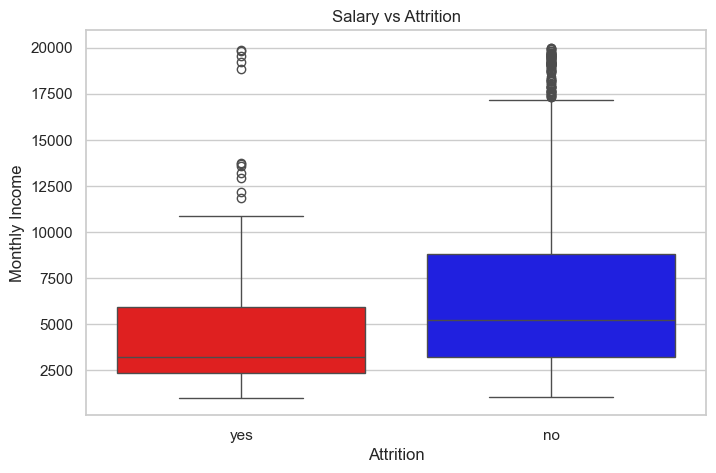

In [8]:
# 8.1 Salary vs Attrition (BOXPLOT)
# Why boxplot?
# → Shows distribution + outliers + comparison between categories

plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df,
            palette={'yes':'red','no':'blue'})

plt.title("Salary vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

C:\Users\22053\AppData\Local\Temp\ipykernel_10528\2552807325.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='JobSatisfaction', data=df,


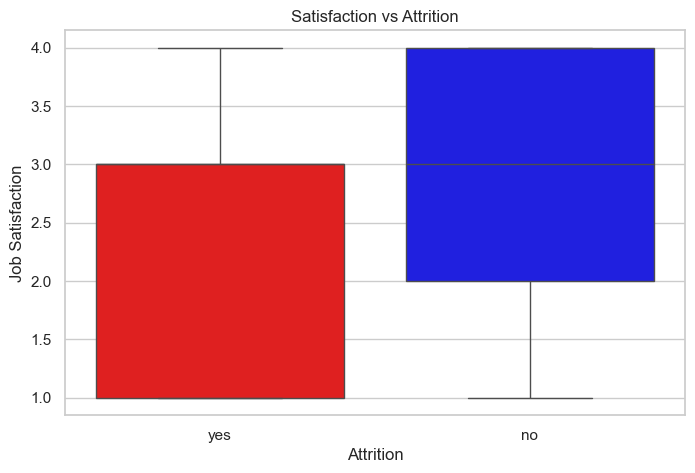

In [9]:
# 8.2 Satisfaction vs Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='JobSatisfaction', data=df,
            palette={'yes':'red','no':'blue'})

plt.title("Satisfaction vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Job Satisfaction")
plt.show()

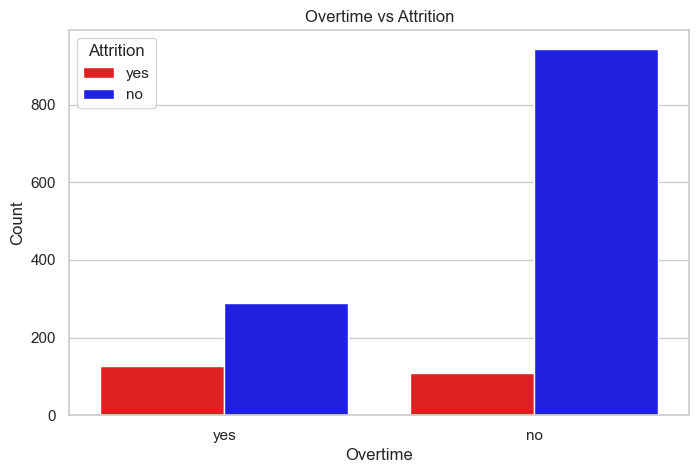

In [10]:
# 8.3 Overtime vs Attrition (COUNTPLOT)
# Why countplot?
# → Best for categorical comparison

plt.figure(figsize=(8,5))
sns.countplot(x='OverTime', hue='Attrition', data=df,
              palette={'yes':'red','no':'blue'})

plt.title("Overtime vs Attrition")
plt.xlabel("Overtime")
plt.ylabel("Count")
plt.show()

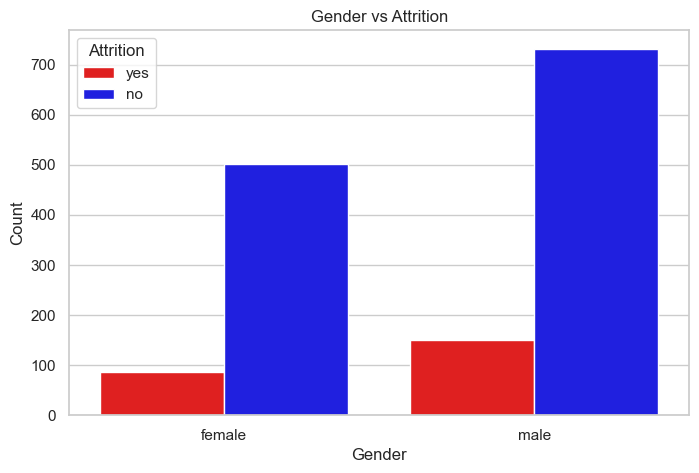

In [11]:
# 8.4 Gender vs Attrition (Color Requirement)
plt.figure(figsize=(8,5))
sns.countplot(x='Gender', hue='Attrition', data=df,
              palette={'yes':'red','no':'blue'})

plt.title("Gender vs Attrition")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

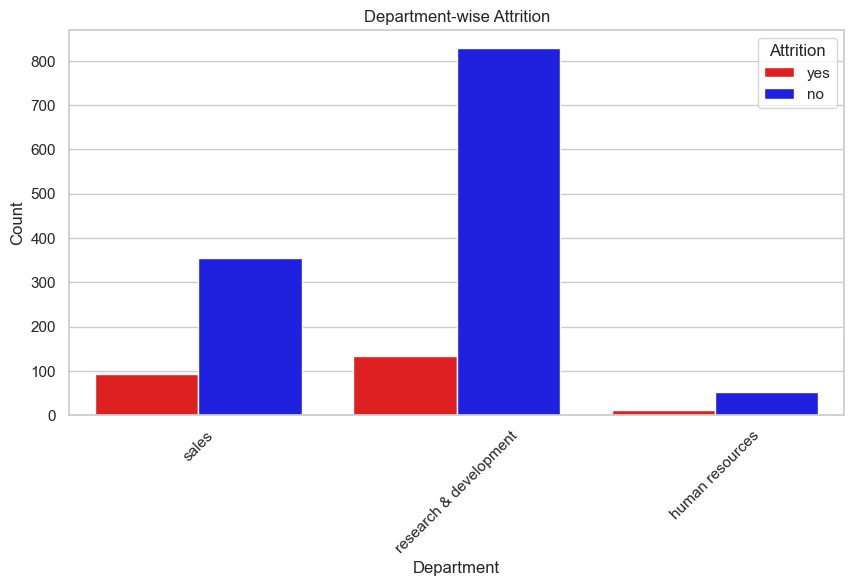

In [12]:
# 8.5 Department Analysis
plt.figure(figsize=(10,5))
sns.countplot(x='Department', hue='Attrition', data=df,
              palette={'yes':'red','no':'blue'})

plt.title("Department-wise Attrition")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

## TABULAR ANALYSIS (PIVOT TABLES)

In [14]:
# Salary vs Attrition
pivot_salary = pd.pivot_table(df,
                             values='Age',
                             index='SalaryCategory',
                             columns='Attrition',
                             aggfunc='count')

print("Salary vs Attrition:\n", pivot_salary)

Salary vs Attrition:
 Attrition        no  yes
SalaryCategory          
low             282  113
medium          610   84
high            341   40


C:\Users\22053\AppData\Local\Temp\ipykernel_10528\3656882017.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_salary = pd.pivot_table(df,


In [15]:
# Department vs Attrition
pivot_dept = pd.pivot_table(df,
                           values='Age',
                           index='Department',
                           columns='Attrition',
                           aggfunc='count')

print("Department vs Attrition:\n", pivot_dept)

Department vs Attrition:
 Attrition                no  yes
Department                      
human resources          51   12
research & development  828  133
sales                   354   92


In [16]:
# Percentage Analysis
dept_percent = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
print("Department Percentage:\n", dept_percent)

Department Percentage:
 Attrition                      no        yes
Department                                  
human resources         80.952381  19.047619
research & development  86.160250  13.839750
sales                   79.372197  20.627803


## GROUPBY ANALYSIS

In [17]:
print(df.groupby('SalaryCategory')['Attrition'].value_counts())
print(df.groupby('ExperienceLevel')['Attrition'].value_counts())

SalaryCategory  Attrition
low             no           282
                yes          113
medium          no           610
                yes           84
high            no           341
                yes           40
Name: count, dtype: int64
ExperienceLevel  Attrition
fresher          no           219
                 yes           86
mid              no           516
                 yes           91
senior           no           492
                 yes           55
Name: count, dtype: int64


C:\Users\22053\AppData\Local\Temp\ipykernel_10528\1237172776.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('SalaryCategory')['Attrition'].value_counts())
C:\Users\22053\AppData\Local\Temp\ipykernel_10528\1237172776.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('ExperienceLevel')['Attrition'].value_counts())


## RISK SEGMENTATION (ADVANCED)

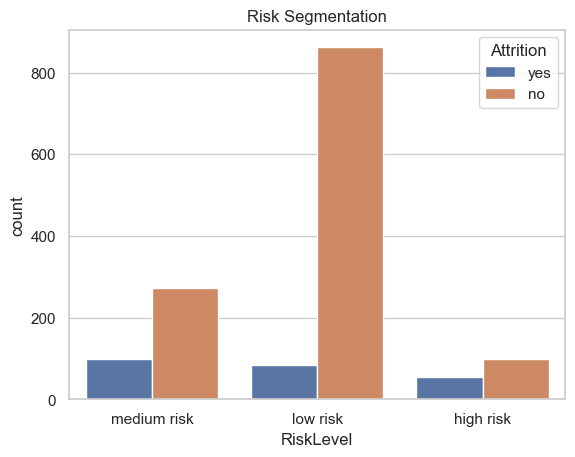

In [18]:
def risk(row):
    if row['SalaryCategory']=='low' and row['JobSatisfaction']<=2:
        return 'high risk'
    elif row['OverTime']=='yes':
        return 'medium risk'
    else:
        return 'low risk'

df['RiskLevel'] = df.apply(risk, axis=1)

sns.countplot(x='RiskLevel', hue='Attrition', data=df)
plt.title("Risk Segmentation")
plt.show()


## Churn/Attrition Distribution Plot

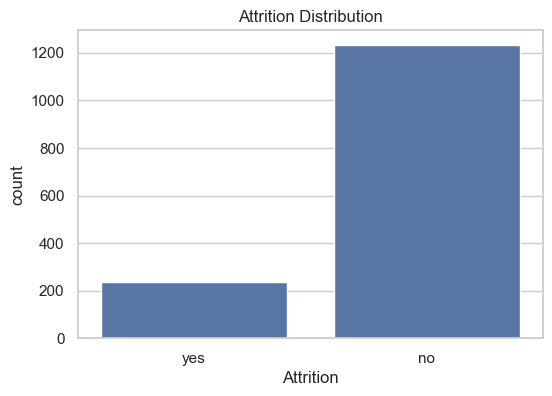

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title('Attrition Distribution')
plt.show()

## Explicit Univariate Analysis Section

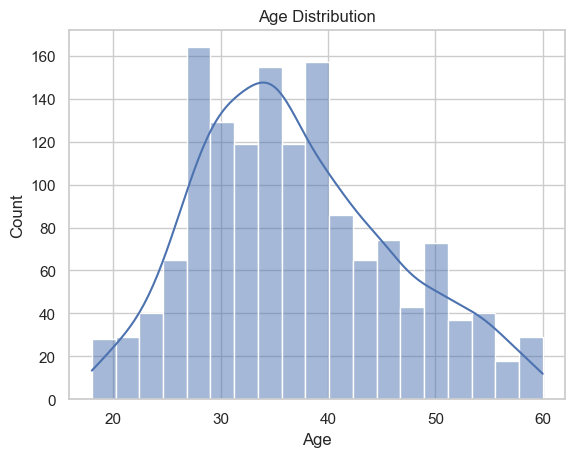

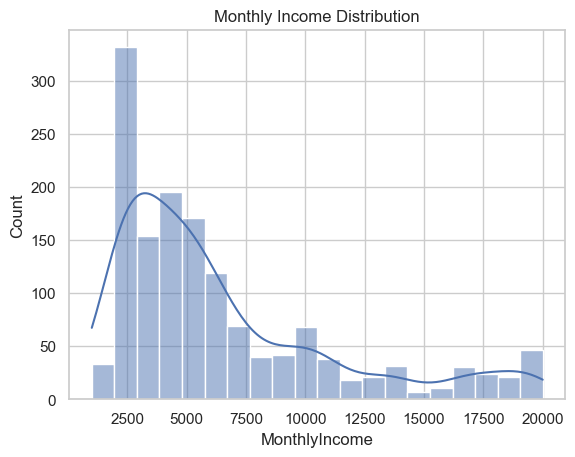

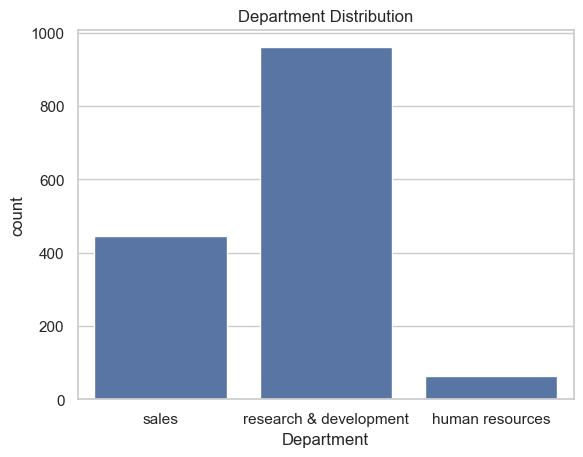

In [21]:
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

sns.histplot(df['MonthlyIncome'], kde=True)
plt.title("Monthly Income Distribution")
plt.show()

sns.countplot(x='Department', data=df)
plt.title("Department Distribution")
plt.show()

## Multivariate Analysis

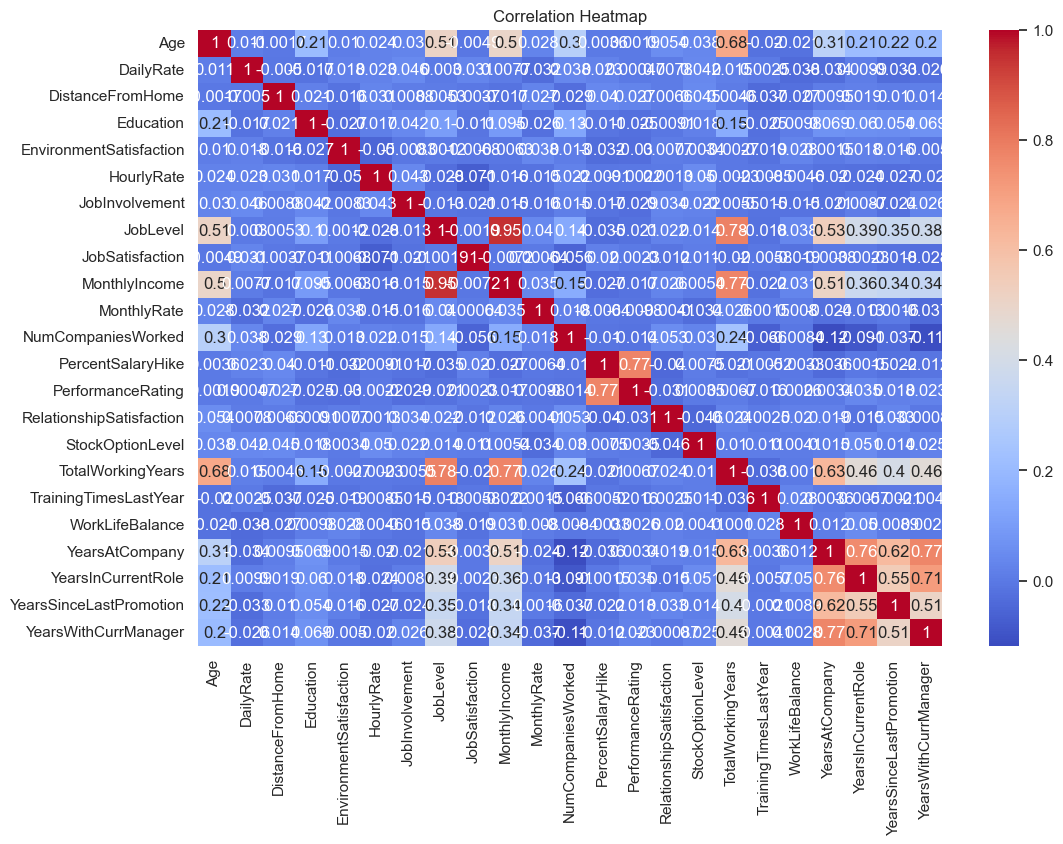

In [13]:
# 8.6 Heatmap (MULTIVARIATE)
# Why heatmap?
# → Shows correlation between multiple variables

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

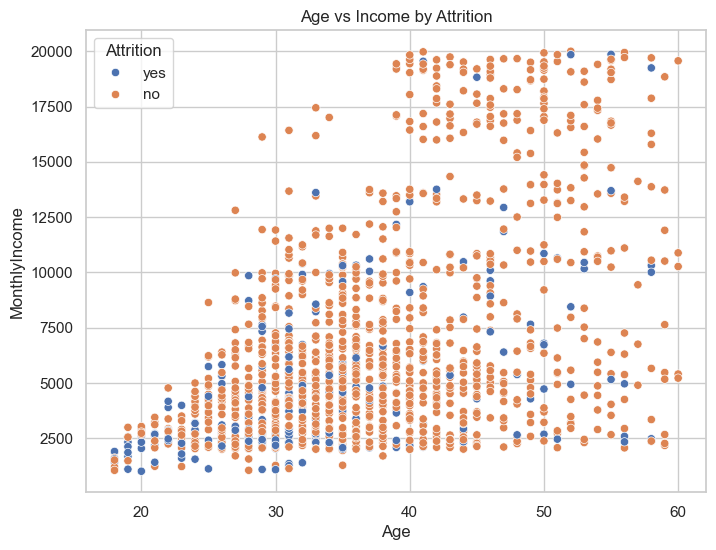

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Age',
    y='MonthlyIncome',
    hue='Attrition',
    data=df
)
plt.title('Age vs Income by Attrition')
plt.show()

- Employees with lower income levels appear more likely to leave the organization regardless of age. Higher-income employees generally exhibit lower attrition rates.

## SAVE CLEAN DATASET

In [19]:
df.to_csv("cleaned_hr_data.csv", index=False)

## FINAL INSIGHTS

### Employees earning lower salaries exhibit higher attrition rates.
### Low job satisfaction is strongly associated with employee turnover.
### Employees working overtime are more likely to leave the organization.
### Early-career employees show higher attrition than experienced employees.
### The Sales department experiences the highest attrition rate.
### HR should focus retention efforts on low-income and overtime employees.
### Improving job satisfaction could significantly reduce attrition.

## Feature Engineering Ideas

## 1. SalaryCategory
   - Group employees into Low, Medium, and High salary bands.

## 2. ExperienceLevel
   - Categorize employees as Junior, Mid-Level, and Senior based on YearsAtCompany.

## 3. OvertimeRiskScore
   - Create a binary feature indicating overtime status.

## 4. PromotionDelayFlag
   - Flag employees who have not received promotions for a long period.

## 5. SatisfactionIndex
   - Combine JobSatisfaction, EnvironmentSatisfaction, and RelationshipSatisfaction into a single score.

## 6. DepartmentAttritionRisk
   - Assign risk levels to departments based on historical attrition rates.

# Recommendations

1. Reduce excessive overtime and monitor employee workload.
2. Improve employee engagement and satisfaction programs.
3. Review compensation structures for high-risk employee groups.
4. Provide clear promotion and career-growth opportunities.
5. Conduct regular employee feedback surveys to identify concerns early.

# Conclusion

- The HR Attrition Analysis identified several important factors influencing employee turnover. Employees with lower salaries, lower job satisfaction, and overtime responsibilities were more likely to leave the organization. Attrition was also higher among early-career employees and certain departments.

- The findings suggest that HR teams should focus on improving employee satisfaction, managing overtime workloads, providing competitive compensation, and creating stronger career development opportunities to reduce attrition and improve retention.